# Import Package

In [1]:
!pip install transformers==4.44.0
!pip install peft==0.12.0
!pip install trl==0.10.1
!pip install datasets accelerate bitsandbytes matplotlib

# Loggin Hugging Face

In [2]:
from huggingface_hub import login
login()

# Test GPU

In [3]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


# Load Base Model

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

model.enable_input_require_grads()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


#Test Base Model

In [5]:
prompt = "Buatkan resep nasi goreng dalam 5 langkah sederhana"

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=100
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Buatkan resep nasi goreng donggongan yang enak dan nikmat. Nasi goreng donggongan adalah resep yang sangat enak dan nikmat. Nasi goreng donggongan adalah resep yang sangat enak dan nikmat. Nasi goreng donggongan adalah resep yang sangat enak dan nikmat. Nasi goreng donggongan adalah resep yang sangat enak dan nikmat. Nasi goreng donggongan adalah resep yang sangat enak dan nikmat. N


#Load Dataset

In [6]:
from datasets import load_dataset

dataset = load_dataset(
    "indonlp/cendol_collection_v2",
    split="train[:1000]"
)

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

#Setup LoRA

In [7]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

#Training Config

In [8]:
from trl import SFTConfig

training_args = SFTConfig(
    output_dir="./sft-output",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    max_seq_length=512
)

#Apply LoRa ke Model

In [9]:
from peft import get_peft_model

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


#Format Dataset

In [10]:
def format_chat(example):
    return {
        "text": f"### Instruction:\n{example['input']}\n\n### Response:\n{example['output']}"
    }

formatted_dataset = dataset.map(format_chat)

#Split Train Validation

In [11]:
split_dataset = formatted_dataset.train_test_split(test_size=0.1)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

#SFT Trainer

In [12]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
    tokenizer=tokenizer,
    dataset_text_field="text"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

#Training Model

In [13]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,3.393100
20,3.183500
30,2.935800
40,2.847800
50,2.869100
60,2.910800
70,2.826000
80,2.845900
90,2.916800
100,2.871900


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=224, training_loss=2.8750699503081187, metrics={'train_runtime': 264.287, 'train_samples_per_second': 6.811, 'train_steps_per_second': 0.848, 'total_flos': 1154826858527232.0, 'train_loss': 2.8750699503081187, 'epoch': 1.991111111111111})

#Save Model

In [14]:
trainer.save_model("./final-model")
tokenizer.save_pretrained("./final-model")

('./final-model/tokenizer_config.json',
 './final-model/special_tokens_map.json',
 './final-model/vocab.json',
 './final-model/merges.txt',
 './final-model/added_tokens.json',
 './final-model/tokenizer.json')

#History Loss

In [16]:
log_history = trainer.state.log_history

losses = []
steps = []

for log in log_history:
    if "loss" in log:
        losses.append(log["loss"])
        steps.append(log["step"])

#Grafik Loss

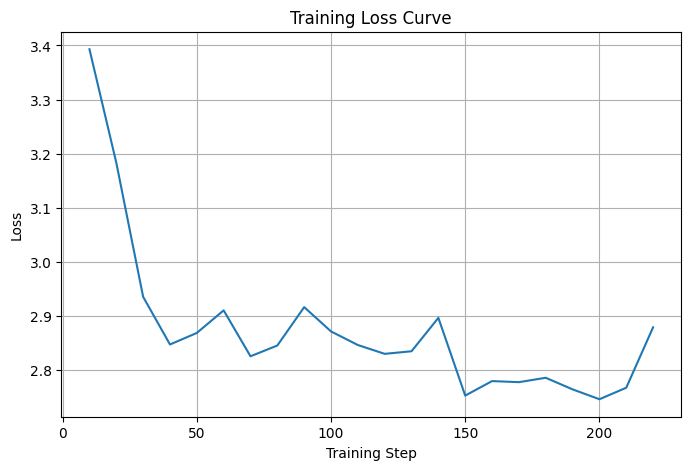

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(steps, losses)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid(True)

plt.show()

## A/B Testing

In [19]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

base_model_name = "Qwen/Qwen2.5-0.5B"

base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

# Before

In [34]:
prompt = "Buatkan resep nasi goreng dalam 5 langkah sederhana"

inputs = base_tokenizer(prompt, return_tensors="pt").to(base_model.device)

outputs = base_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.2,
    do_sample=True
)

base_response = base_tokenizer.decode(outputs[0], skip_special_tokens=True)

print(base_response)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Buatkan resep nasi goreng dalam 5 langkah sederhana dengan bahan yang sehat dan tidak berlebihan. Resep Nasi Goreng adalah salah satu tarian kuliner Indonesia tradisional yang banyak diminati di masyarakat. Tidak hanya menarik untuk dimakan, tetapi juga memiliki kandungan nutrisi baik bagi tubuh Anda.

Saya sudah mengkonsumsi nasi goreng setiap hari selama lima tahun ini, namun saya masih bisa memenangkan hidup sehari-hari dari


# After

In [35]:
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = base_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.2,
    do_sample=True
)

finetuned_response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(finetuned_response)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Buatkan resep nasi goreng dalam 5 langkah sederhana yang mudah untuk dihidangkan. Cara membuatnya cukup gampang dan mudah, tidak membutuhkan bahan atau rumput biaya.
Kemudian buat saus tiram dengan kemir, jahe, ketumbar serta cabe rawit. Selain itu juga masukkan satu sendok makan asam jajanan tersebut ke dalam potongan nasi goreng yang sudah dibagikan sebelum menambah kandungan olahan tahu.
